In [423]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [424]:
import h5py
def load_dataset():
    train_dataset = h5py.File("train_signs.h5")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset =  h5py.File("test_signs.h5")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes

    return X_train, Y_train, X_test, Y_test, classes
train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1080,)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (120,)


In [425]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

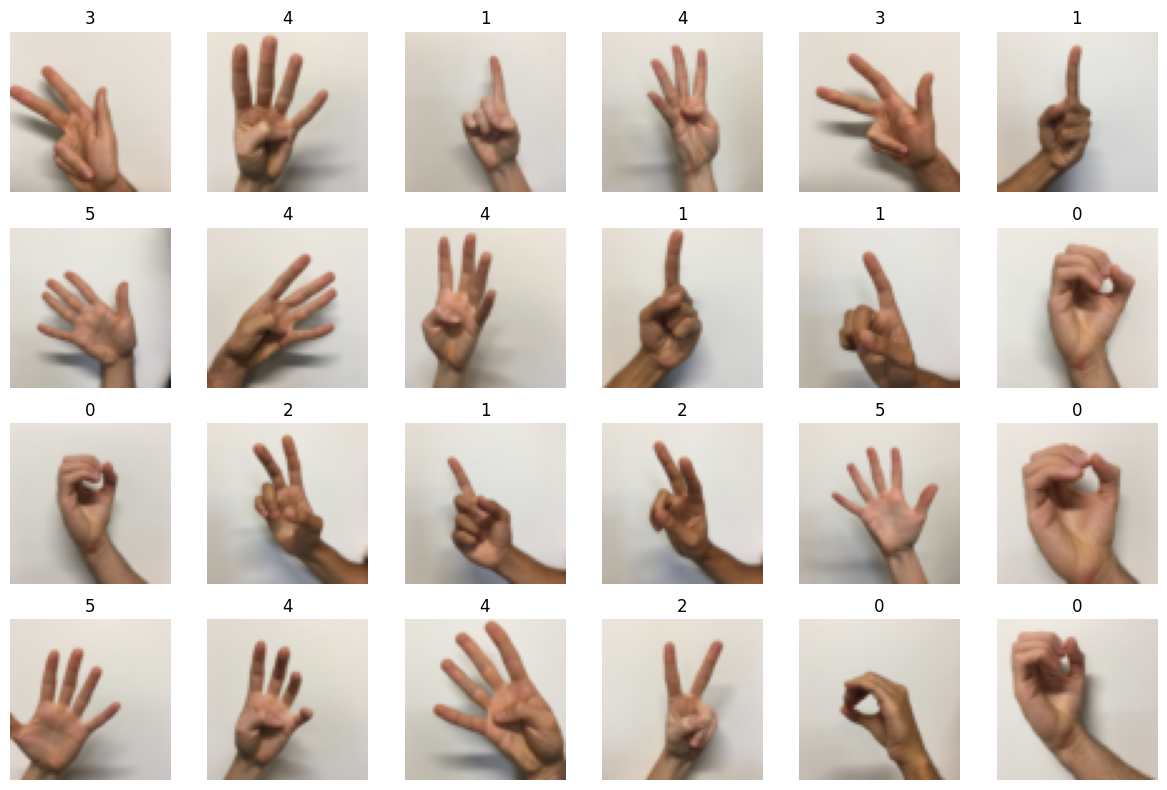

In [426]:
plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

##Data processing

In [427]:
dimData = np.prod(train_data.shape[1:])
train_data = train_data.reshape(train_data.shape[0], dimData)
test_data = test_data.reshape(test_data.shape[0], dimData)

In [428]:
print(train_data.shape)
print(train_data)

(1080, 12288)
[[227 220 214 ... 208 209 209]
 [238 232 223 ... 215 204 192]
 [228 220 208 ... 211 207 202]
 ...
 [235 226 216 ... 200 192 182]
 [233 226 217 ... 204 201 198]
 [230 220 209 ... 202 199 197]]


In [429]:
train_data = train_data.astype('float32')
test_data = test_data.astype('float32')

train_data /= 255
test_data /= 255

In [430]:
train_data

array([[0.8901961 , 0.8627451 , 0.8392157 , ..., 0.8156863 , 0.81960785,
        0.81960785],
       [0.93333334, 0.9098039 , 0.8745098 , ..., 0.84313726, 0.8       ,
        0.7529412 ],
       [0.89411765, 0.8627451 , 0.8156863 , ..., 0.827451  , 0.8117647 ,
        0.7921569 ],
       ...,
       [0.92156863, 0.8862745 , 0.84705883, ..., 0.78431374, 0.7529412 ,
        0.7137255 ],
       [0.9137255 , 0.8862745 , 0.8509804 , ..., 0.8       , 0.7882353 ,
        0.7764706 ],
       [0.9019608 , 0.8627451 , 0.81960785, ..., 0.7921569 , 0.78039217,
        0.77254903]], dtype=float32)

In [431]:
Y_train_one_hot = to_categorical(train_labels)
Y_test_one_hot = to_categorical(test_labels)

print('Original label [0] : ', train_labels[0])
print('After conversion to categorical ( one-hot ) : ', Y_train_one_hot[0])

Original label [0] :  5
After conversion to categorical ( one-hot ) :  [0. 0. 0. 0. 0. 1.]


In [432]:
classes = np.unique(train_labels)
nClasses = len(classes)
nClasses

6

In [433]:
train_data = train_data.reshape(train_data.shape[0], -1)
test_data = test_data.reshape(test_data.shape[0], -1)

##Building a model

In [434]:
model1 = Sequential([
    Dense(256, activation='relu', input_shape=(12288,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(6, activation='softmax')
])

In [435]:
model1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [436]:
history = model1.fit(train_data, Y_train_one_hot, batch_size=256, epochs=25, verbose=1,
                   validation_data=(test_data, Y_test_one_hot))

Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 461ms/step - accuracy: 0.2944 - loss: 1.7728 - val_accuracy: 0.2417 - val_loss: 1.8351
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5889 - loss: 1.1844 - val_accuracy: 0.2083 - val_loss: 2.1935
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6667 - loss: 0.9632 - val_accuracy: 0.2917 - val_loss: 2.4995
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7546 - loss: 0.7973 - val_accuracy: 0.1917 - val_loss: 2.7370
Epoch 5/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7981 - loss: 0.6959 - val_accuracy: 0.1833 - val_loss: 2.9774
Epoch 6/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8426 - loss: 0.6043 - val_accuracy: 0.2000 - val_loss: 3.0594
Epoch 7/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8694 - loss: 0.5379 - val_accuracy: 0.2000 - val_loss: 3.0237
Epoch 8/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8926 - loss: 0.4903 - val_accuracy: 0.2333 - val_loss: 2.9117

In [437]:
[test_loss, test_acc] = model1.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.4583 - loss: 1.5009
Evaluation result on Test Data : Loss = 1.5009236335754395, accuracy = 0.4583333432674408


Text(0.5, 1.0, 'Accuracy Curves')

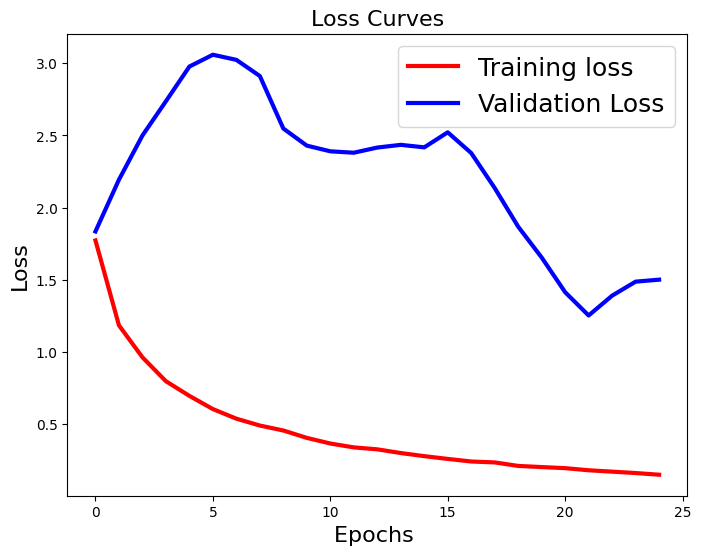

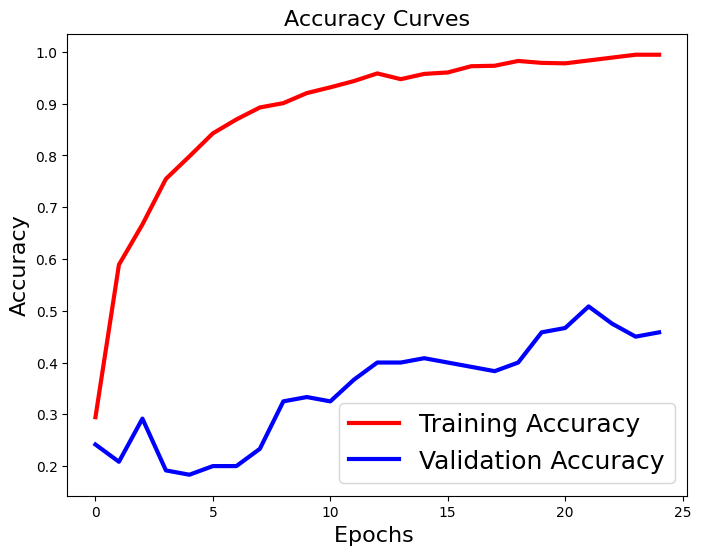

In [438]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

##Changing the number of hidden layer

In [439]:
model2 = Sequential([
    Dense(256, activation='relu', input_shape=(12288,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(6, activation='softmax')
])

In [440]:
model2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [441]:
history = model2.fit(train_data, Y_train_one_hot, batch_size=256, epochs=10, verbose=1,
                   validation_data=(test_data, Y_test_one_hot))

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 650ms/step - accuracy: 0.2028 - loss: 2.1382 - val_accuracy: 0.2083 - val_loss: 2.1133
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3870 - loss: 1.5468 - val_accuracy: 0.1917 - val_loss: 2.3041
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4926 - loss: 1.3260 - val_accuracy: 0.2333 - val_loss: 2.5229
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5398 - loss: 1.1774 - val_accuracy: 0.1667 - val_loss: 2.6418
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6102 - loss: 1.0408 - val_accuracy: 0.1667 - val_loss: 2.6695
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6537 - loss: 0.9518 - val_accuracy: 0.1667 - val_loss: 2.7546
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6676 - loss: 0.8995 - val_accuracy: 0.1667 - val_loss: 2.8034
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7120 - loss: 0.8247 - val_accuracy: 0.1667 - val_loss: 2.8714

In [442]:
[test_loss, test_acc] = model2.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.1667 - loss: 2.9869
Evaluation result on Test Data : Loss = 2.986938238143921, accuracy = 0.1666666716337204


Text(0.5, 1.0, 'Accuracy Curves')

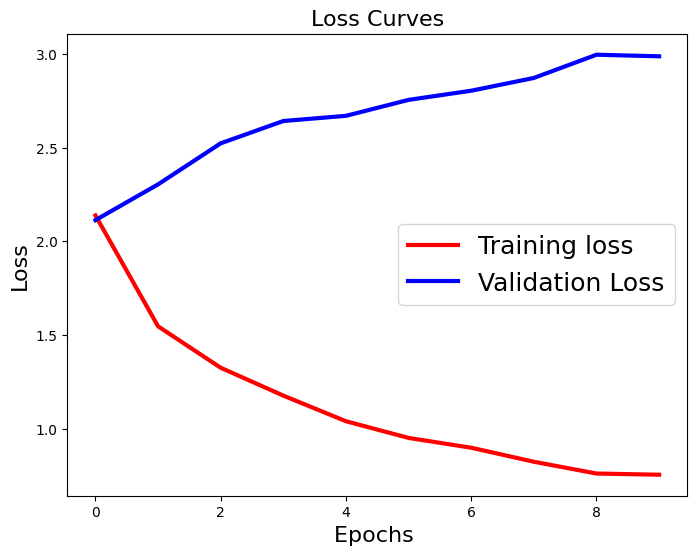

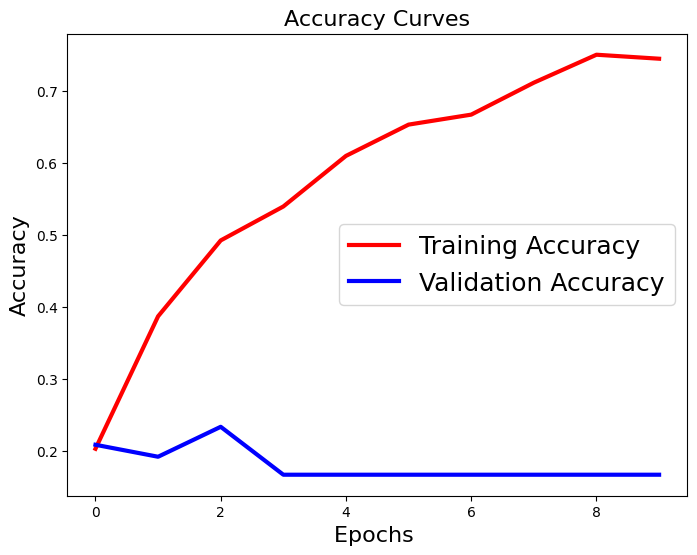

In [443]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

##Changing the activation function

In [444]:
model3 = Sequential([
    Dense(256, activation='tanh', input_shape=(12288,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='tanh'),

    Dense(6, activation='softmax')
])

In [445]:
model3.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [446]:
history = model3.fit(train_data, Y_train_one_hot, batch_size=256, epochs=40, verbose=1,
                   validation_data=(test_data, Y_test_one_hot))

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 622ms/step - accuracy: 0.3167 - loss: 1.7287 - val_accuracy: 0.2833 - val_loss: 2.2925
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5704 - loss: 1.1603 - val_accuracy: 0.3500 - val_loss: 2.1069
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6704 - loss: 0.9633 - val_accuracy: 0.4250 - val_loss: 1.9808
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7065 - loss: 0.8516 - val_accuracy: 0.4083 - val_loss: 1.8967
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7380 - loss: 0.7804 - val_accuracy: 0.3583 - val_loss: 1.8188
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7750 - loss: 0.6908 - val_accuracy: 0.4250 - val_loss: 1.7817
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7926 - loss: 0.6415 - val_accuracy: 0.4250 - val_loss: 1.7228
Epoch 8/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8250 - loss: 0.5888 - val_accuracy: 0.4333 - val_loss: 1.6931

In [447]:
[test_loss, test_acc] = model3.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.6000 - loss: 1.0331
Evaluation result on Test Data : Loss = 1.0331416130065918, accuracy = 0.6000000238418579


Text(0.5, 1.0, 'Accuracy Curves')

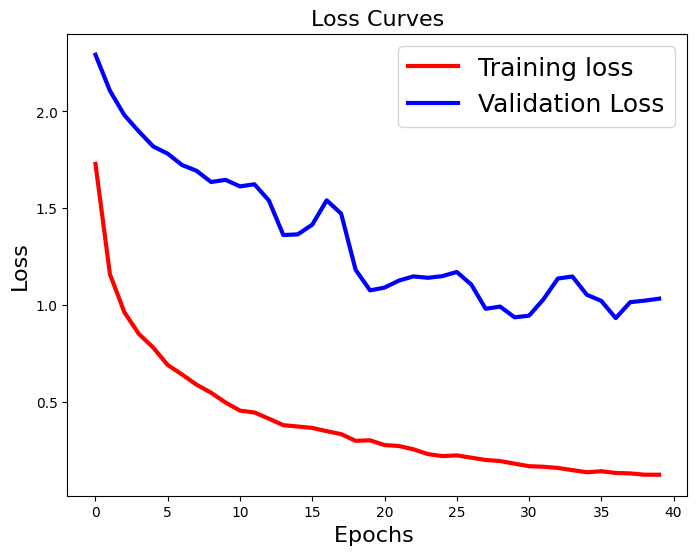

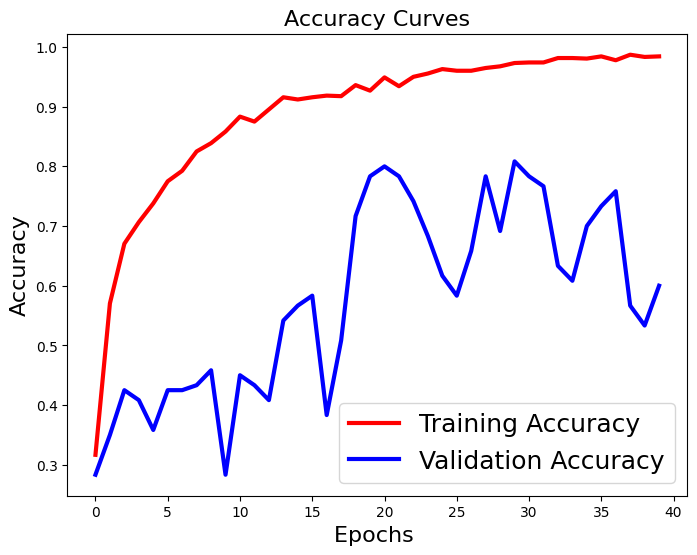

In [448]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

##Changing the dropout ratio

In [449]:
model4 = Sequential([
    Dense(256, activation='relu', input_shape=(12288,)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),

    Dense(64, activation='relu'),

    Dense(6, activation='softmax')
])

In [450]:
model4.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [451]:
history = model4.fit(train_data, Y_train_one_hot, batch_size=256, epochs=40, verbose=1,
                   validation_data=(test_data, Y_test_one_hot))

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 656ms/step - accuracy: 0.2093 - loss: 2.4441 - val_accuracy: 0.1667 - val_loss: 2.5182
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2454 - loss: 2.2354 - val_accuracy: 0.1667 - val_loss: 3.4362
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2852 - loss: 2.0407 - val_accuracy: 0.1667 - val_loss: 4.0688
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3343 - loss: 1.8810 - val_accuracy: 0.1667 - val_loss: 4.3829
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3491 - loss: 1.8676 - val_accuracy: 0.1667 - val_loss: 4.7190
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3528 - loss: 1.7907 - val_accuracy: 0.1667 - val_loss: 4.9484
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4093 - loss: 1.6305 - val_accuracy: 0.1667 - val_loss: 4.9731
Epoch 8/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4083 - loss: 1.5828 - val_accuracy: 0.1667 - val_loss: 4.9725

In [452]:
[test_loss, test_acc] = model4.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6500 - loss: 1.0160
Evaluation result on Test Data : Loss = 1.0160048007965088, accuracy = 0.6499999761581421


Text(0.5, 1.0, 'Accuracy Curves')

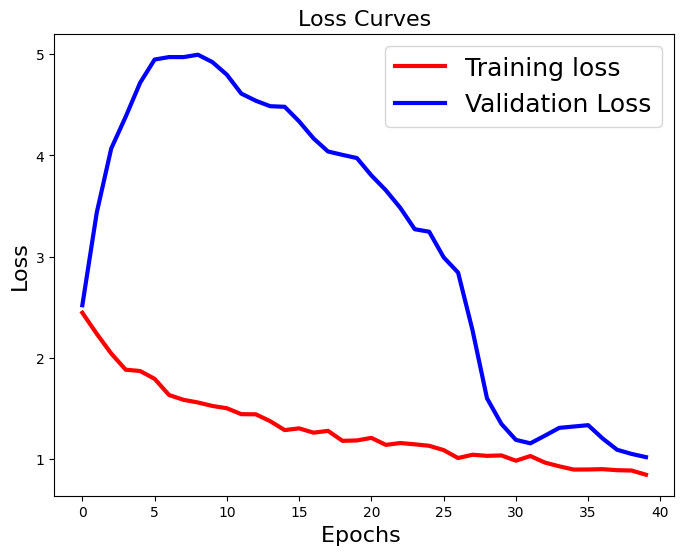

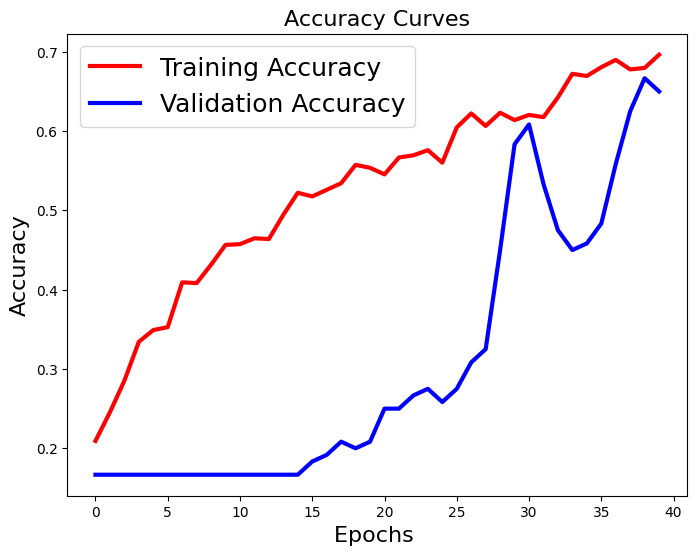

In [453]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

##Final model

In [473]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(12288,)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(6, activation='softmax')
])

In [474]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [475]:
history = model.fit(train_data, Y_train_one_hot, batch_size=256, epochs=50, verbose=1,
                   validation_data=(test_data, Y_test_one_hot))

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 634ms/step - accuracy: 0.2083 - loss: 2.1875 - val_accuracy: 0.1667 - val_loss: 2.0170
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2898 - loss: 1.8691 - val_accuracy: 0.1750 - val_loss: 2.2713
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4046 - loss: 1.5853 - val_accuracy: 0.1750 - val_loss: 2.4444
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4324 - loss: 1.5010 - val_accuracy: 0.1750 - val_loss: 2.6112
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4685 - loss: 1.3967 - val_accuracy: 0.1750 - val_loss: 2.6870
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5231 - loss: 1.2987 - val_accuracy: 0.1833 - val_loss: 2.6095
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5361 - loss: 1.2406 - val_accuracy: 0.2417 - val_loss: 2.6279
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5741 - loss: 1.1611 - val_accuracy: 0.2083 - val_loss: 2.4756

In [476]:
[test_loss, test_acc] = model.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.7833 - loss: 0.6418
Evaluation result on Test Data : Loss = 0.6418206691741943, accuracy = 0.7833333611488342


Text(0.5, 1.0, 'Accuracy Curves')

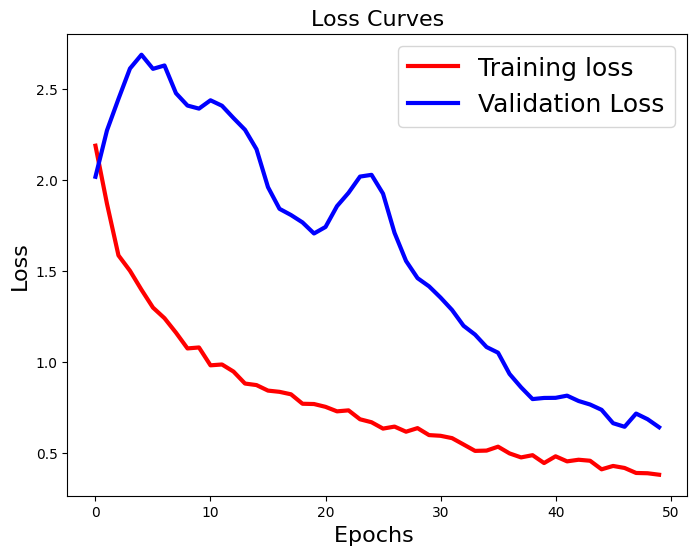

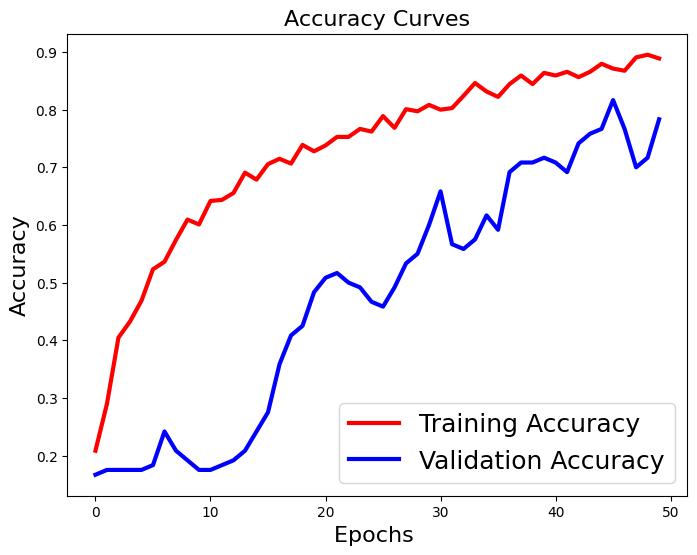

In [477]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)